In [1]:
import zarr
import s3fs
import numpy as np
from scipy.linalg import solve_banded
import matplotlib.pyplot as plt

S3_BUCKET = "simulations"
STORE_PATH = "flow_export/A1"

fs = s3fs.S3FileSystem(profile='default', client_kwargs={
        'endpoint_url': 'http://localhost:9000'
    })

s3_map = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/data.zarr", s3=fs)
z = zarr.open(
    store=s3_map,
    mode="r",
)

store = s3fs.S3Map(root=f"{S3_BUCKET}/{STORE_PATH}/channel.zarr", s3=fs)
channel_z = zarr.open(
    store=store,
    mode="r",
)
channel = {'x': channel_z['x'][:], 'y': channel_z['y'][:], 'z': channel_z['z'][:]}


In [2]:
z.shape

(1694, 5, 128, 129, 128)

In [3]:
data = z[510:1010:50]

In [4]:
data.shape

(10, 5, 128, 129, 128)

In [5]:
# https://www.incompact3d.com/uploads/5/8/7/2/58724623/_user_guide_incompact3d_v2.pdf
# Citation:
# L E.,F V. L S.,2011 Straigh forward high-order numerical dissipation via the viscous term for Direct and Large Eddy Simulatin, J.Comp.Phys.,230(9),3270-3275.
# Solve system: A . x = rhs
def derive_compact_1st_degree_6th_order_dirichlet(field, direction, d):
    x = np.moveaxis(field, direction, 0)
    shape_reordered = x.shape
    rhs = np.zeros_like(x)
    length = field.shape[direction]
    A = np.zeros((3, x.shape[0]))
    alpha = 1 / 3
    a = 14 / 9
    b = 1 / 9

    rhs[2:-2] = a * (x[3:-1] - x[1:-3]) / (2 * d) + b * (x[4:] - x[0:-4]) / (4 * d)
    rhs[0] = (-5 * x[0] + 4 * x[1] + 1 * x[2]) / (2 * d)
    rhs[1] = ((3 / 2) * (x[2] - x[0])) / (2 * d)
    rhs[-2] = -1 * ((3 / 2) * (x[-3] - x[-1])) / (2 * d)
    rhs[-1] = -1 * (-5 * x[-1] + 4 * x[-2] + 1 * x[-3]) / (2 * d)

    A[0, 2:] = alpha
    A[1, :] = 1
    A[2, :-2] = alpha
    A[0, 1] = 2
    A[2, -2] = 2
    A[0, 2] = 1 / 4
    A[2, 0] = 1 / 4
    A[0, -1] = 1 / 4
    A[2, -3] = 1 / 4

    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), A, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime


def broadcast_to(source, target, index):
    d = source.shape
    target_shape = list(target.shape)
    for i in range(len(target_shape)):
        if i != index:
            target_shape[i] = 1
    return source.reshape(tuple(target_shape))


def derive_fft(u, direction, h):
    n = u.shape[direction]
    k = 2.0 * np.pi * np.fft.fftfreq(n, d=h)
    k_broad = broadcast_to(k, u, direction)
    u_hat = np.fft.fftn(u, axes=(direction,))
    u_hat_prime = 1.0j * k_broad * u_hat
    return np.fft.ifftn(u_hat_prime, axes=(direction,)).real


def get_grad_func(channel):
    
    dx = channel["x"][1] - channel["x"][0]  # X is uniform
    dz = channel["z"][1] - channel["z"][0]  # Z is uniform
    compute_dy = channel["y"][-1] / (channel["y"].shape[0] - 1)  # computational space of y is uniform
    # delta_yp = np.gradient(yp, compute_dy, edge_order=1)
    # y_stretching = 1.0 / delta_yp
    
    yly   = channel["y"][-1]      # channel height
    beta  = 0.259    # stretching parameter
    ny    = channel["y"].shape[0]
    nym   = ny - 1   # walls present
    
    yinf  = -yly/2
    alpha = abs((-yinf - np.sqrt(np.pi**2*beta**2 + yinf**2)) / (2*beta*yinf))
    
    yeta  = (np.arange(1, ny+1) - 1)/nym - 0.5          # computational coord
    ppy   = yly*(alpha/np.pi + (1/(np.pi*beta))*np.sin(np.pi*yeta)**2)   # EXACT metric factor

    # true incompact grad should use use compact too
    def grad(field):
        T, C, X, Y, Z = field.shape
        grad = np.zeros((T, C, 3, X, Y, Z))
        grad[:, :, 0, :, :, :] = derive_fft(field, 2, dx)
        grad[:, :, 1, :, :, :] = derive_compact_1st_degree_6th_order_dirichlet(field, 3, compute_dy) * ppy[None, None, None, :, None]
        grad[:, :, 2, :, :, :] = derive_fft(field, 4, dz)
        return grad

    return grad

In [6]:
def rmse(X, Y):
    return np.sqrt(np.mean((X - Y) ** 2))
def rel_rmse(X, Y):
    return rmse(X, Y) / rmse(Y, 0)

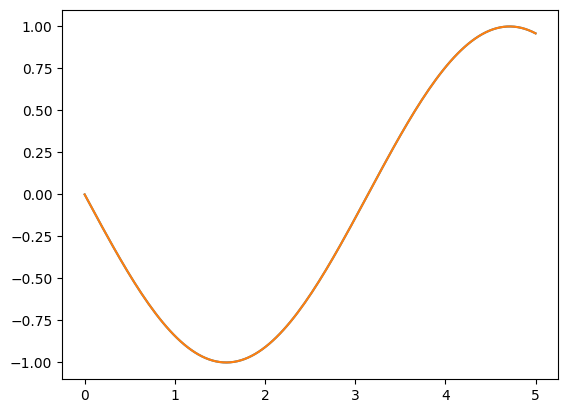

1.0789627131634104e-06
1.486760965514642e-06


In [7]:
r = 128
L = 5
d = L / (r - 1)
x = np.linspace(0, L, r)
comp = derive_compact_1st_degree_6th_order_dirichlet(np.cos(x), 0, d)
targ = -np.sin(x)
plt.plot(x, comp)
plt.plot(x, targ)
plt.show()
print(rmse(comp, targ))
print(rel_rmse(comp, targ))

In [8]:
grad = get_grad_func(channel)

In [9]:
u_grad = grad(data[:, :3])

In [10]:
u_grad.shape

(10, 3, 3, 128, 129, 128)

In [11]:
Q = -0.5 * np.einsum('tij..., tji...->t...', u_grad, u_grad)

In [12]:
rel_rmse(Q, data[:, 4])

np.float64(0.03875323002926186)

In [13]:
rel_rmse(Q, data[:, 4])

np.float64(0.03875323002926186)

In [14]:
np.sqrt(np.mean(data[:, 4, :, 0, :] ** 2))

np.float32(0.012485772)

In [15]:
np.sqrt(np.mean(data[:, 4, :, -1, :] ** 2))

np.float32(0.012407701)

In [16]:
np.sqrt(np.mean(Q[:, :, 0, :] ** 2))

np.float64(0.012490642415270918)

In [17]:
np.sqrt(np.mean(Q[:, :, -1, :] ** 2))

np.float64(0.012412542754052848)

In [18]:
y = channel["y"]

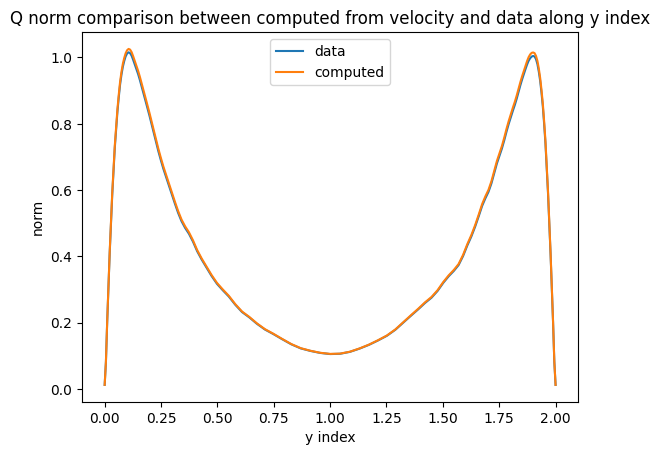

In [19]:
plt.title("Q norm comparison between computed from velocity and data along y index")
plt.plot(y, np.sqrt(np.mean((data[:, 4]) ** 2, axis=(0, 1, 3))), label="data")
plt.plot(y, np.sqrt(np.mean((Q) ** 2, axis=(0, 1, 3))), label="computed")
plt.legend()
plt.xlabel("y index")
plt.ylabel("norm")
plt.show()

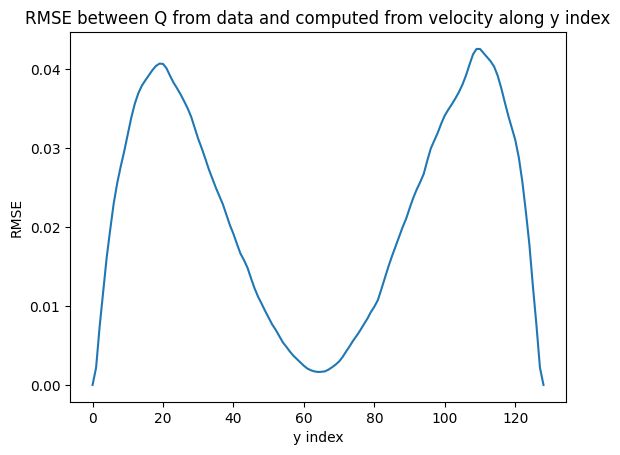

In [20]:
plt.title("RMSE between Q from data and computed from velocity along y index")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))))
plt.xlabel("y index")
plt.ylabel("RMSE")
plt.show()

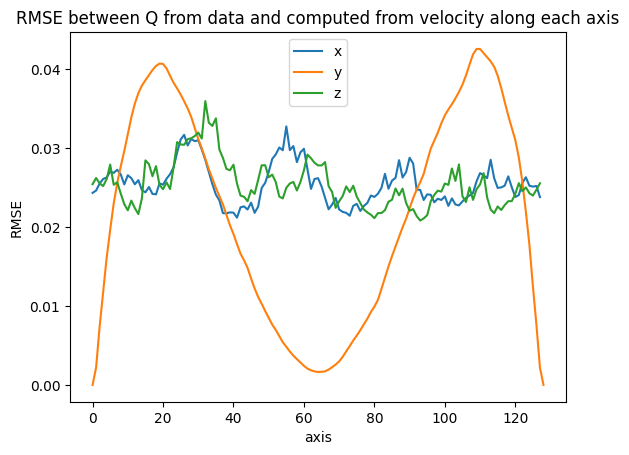

In [21]:
plt.title("RMSE between Q from data and computed from velocity along each axis")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 2, 3))), label="x")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))), label="y")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 2))), label="z")
plt.legend()
plt.xlabel("axis")
plt.ylabel("RMSE")
plt.show()

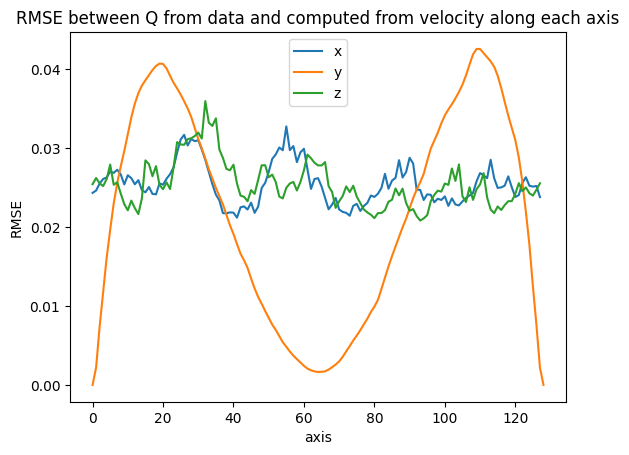

In [22]:
plt.title("RMSE between Q from data and computed from velocity along each axis")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 2, 3))), label="x")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))), label="y")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 2))), label="z")
plt.legend()
plt.xlabel("axis")
plt.ylabel("RMSE")
plt.show()

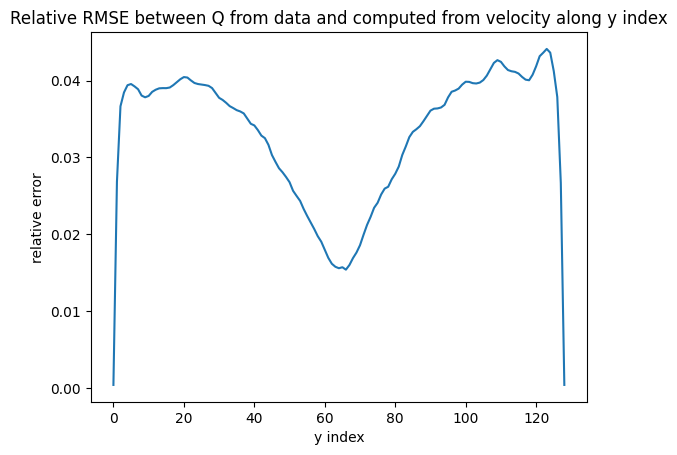

In [23]:
plt.title("Relative RMSE between Q from data and computed from velocity along y index")
plt.plot(np.sqrt(np.mean((Q - data[:, 4]) ** 2, axis=(0, 1, 3))) / np.sqrt(np.mean((data[:, 4]) ** 2, axis=(0, 1, 3))))
plt.xlabel("y index")
plt.ylabel("relative error")
plt.show()

In [24]:
rel_rmse(Q, data[:, 4])

np.float64(0.03875323002926186)

In [25]:
u_div = u_grad[:, 0, 0] + u_grad[:, 1, 1] + u_grad[:, 2, 2]

In [26]:
u_div.mean()

np.float64(-4.041042938087284e-12)

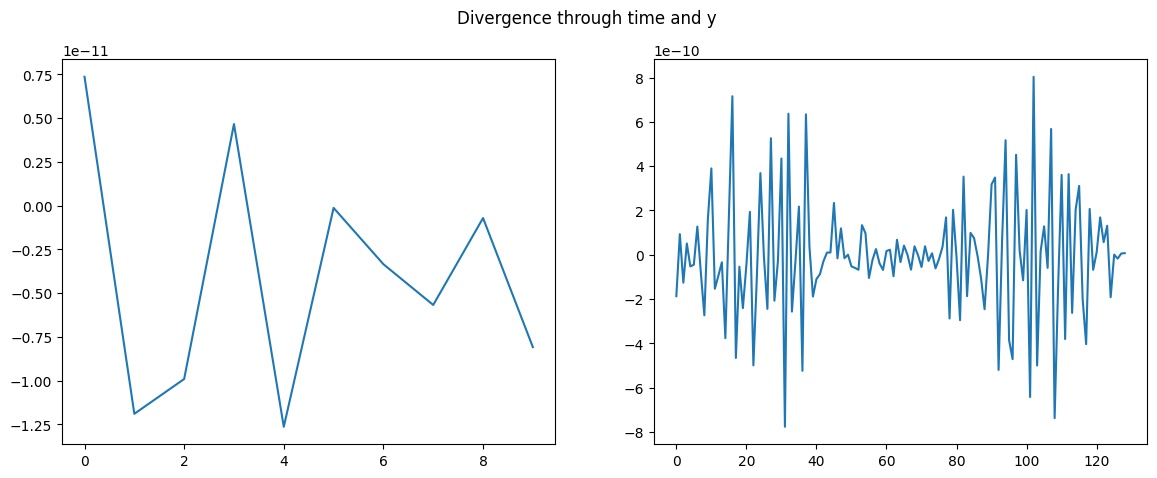

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Divergence through time and y")
ax[0].plot(u_div.mean(axis=(1, 2, 3)))
ax[1].plot(u_div.mean(axis=(0, 1, 3)))
plt.show()

In [28]:
bc = (data[:, :3, :, 0, :] + data[:, :3, :, -1, :] ).sum()

In [29]:
bc

np.float32(-1.1877432e-10)

In [30]:
xz_mean = data[:, :3].mean((2, 4))
stationarity = xz_mean[1:] - xz_mean[:-1]

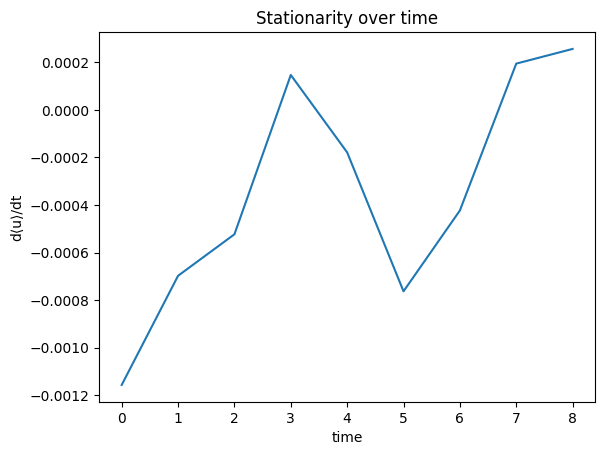

In [31]:
plt.title("Stationarity over time")
plt.plot(stationarity.mean((1, 2)))
plt.xlabel("time")
plt.ylabel("d⟨u⟩/dt")
plt.show()

In [32]:
nu = 1/4763
dy_wall = channel["y"][1] - channel["y"][0]
u_tau = np.array([np.sqrt(nu * data[:, 0].mean((0, 1, 3))[1] / dy_wall),  np.sqrt(nu * data[:, 0].mean((0, 1, 3))[-2] / (channel["y"][-1] - channel["y"][-2]))])

In [33]:
re_t = u_tau.mean() / nu

In [34]:
re_t

np.float64(202.56822938441587)

In [35]:
u_tau

array([0.04239113, 0.04266797])

In [36]:
data[:, 0].mean((0, 1, 3))[0]

np.float32(9.15934e-17)

In [37]:
data[:, -1].mean((0, 1, 3))[0]

np.float32(-0.0033753135)

In [38]:
data.shape

(10, 5, 128, 129, 128)

In [48]:
# https://www.incompact3d.com/uploads/5/8/7/2/58724623/_user_guide_incompact3d_v2.pdf
# Citation:
# L E.,F V. L S.,2011 Straigh forward high-order numerical dissipation via the viscous term for Direct and Large Eddy Simulatin, J.Comp.Phys.,230(9),3270-3275.
# Solve system: A . x = rhs
def derive_compact_2nd_degree_6th_order_dirichlet(field, direction, d):
    if len(field.shape) > 1:
        # Rhs is flat so bc would be bad for sure
        raise Warning("Untested case, expected to fail")
    x = np.moveaxis(field, direction, 0)
    shape_reordered = x.shape
    rhs = np.zeros_like(x)
    length = field.shape[direction]
    A = np.zeros((3, x.shape[0]))
    alpha = 2 / 11
    a = 12 / 11
    b = 3 / 11

    rhs[2:-2] = a * (x[3:-1] - 2 * x[2:-2] + x[1:-3]) / (d * d) + b * (x[4:] - 2 * x[2:-2] + x[0:-4]) / (4 * d * d)
    rhs[0] = (13 * x[0] - 27 * x[1] + 15 * x[2] - 1 * x[3]) / (d * d)
    rhs[1] = ((6 / 5) * (x[2] - 2 * x[1] + x[0])) / (d * d)
    rhs[-2] = ((6 / 5) * (x[-3] - 2 * x[-2] + x[-1])) / (d * d)
    rhs[-1] = (13 * x[-1] - 27 * x[-2] + 15 * x[-3] - 1 * x[-4]) / (d * d)

    A[0, 2:] = alpha
    A[1, :] = 1
    A[2, :-2] = alpha
    A[0, 1] = 11
    A[2, -2] = 11
    A[0, 2] = 1 / 10
    A[2, 0] = 1 / 10
    A[0, -1] = 1 / 10
    A[2, -3] = 1 / 10

    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), A, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime


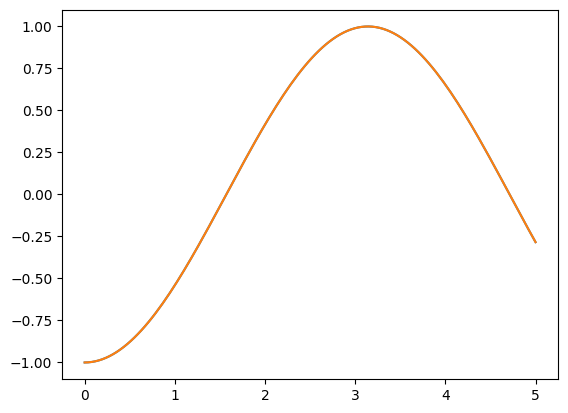

3.6373969945576327e-06
5.286938185209613e-06


In [49]:
r = 128
L = 5
d = L / (r - 1)
x = np.linspace(0, L, r)
comp = derive_compact_2nd_degree_6th_order_dirichlet(np.cos(x), 0, d)
targ = -np.cos(x)
plt.plot(x, comp)
plt.plot(x, targ)
plt.show()
print(rmse(comp, targ))
print(rel_rmse(comp, targ))

In [205]:
# https://www.incompact3d.com/uploads/5/8/7/2/58724623/_user_guide_incompact3d_v2.pdf
# Citation:
# L E.,F V. L S.,2011 Straigh forward high-order numerical dissipation via the viscous term for Direct and Large Eddy Simulatin, J.Comp.Phys.,230(9),3270-3275.
# Solve system: A . x = rhs
def derive_compact_2nd_degree_6th_order_neumann(field, direction, d):
    if len(field.shape) > 1:
        # Rhs is flat so bc would be bad for sure
        raise Warning("Untested case, expected to fail")
    x = np.moveaxis(field, direction, 0)
    shape_reordered = x.shape
    rhs = np.zeros_like(x)
    length = field.shape[direction]
    A = np.zeros((3, x.shape[0]))
    alpha = 2 / 11
    a = 12 / 11
    b = 3 / 11
    # Build x with neumann bc, f_0 -> f_2, f_-1 -> f_3, f"_0 -> f"_2
    # here f is the field function, ranging from 1 to nx included
    xn = np.pad(x, pad_width=2, mode="reflect")
    rhs[:] = a * (xn[3:-1] - 2 * xn[2:-2] + xn[1:-3]) / (d * d) + b * (xn[4:] - 2 * xn[2:-2] + xn[0:-4]) / (4 * d * d)

    A[0, 2:] = alpha
    A[1, :] = 1
    A[2, :-2] = alpha
    A[0, 1] = 2 * alpha
    A[2, -2] = 2 * alpha

    rhs_reshaped = rhs.reshape(length, -1)
    field_prime_reshaped = solve_banded((1, 1), A, rhs_reshaped)
    field_prime_reshaped = field_prime_reshaped.reshape(shape_reordered)
    field_prime = np.moveaxis(field_prime_reshaped, 0, direction)
    return field_prime


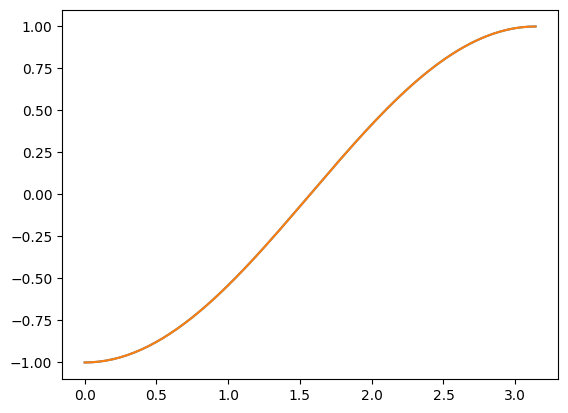

3.038837393258869e-13
4.2808754193135476e-13


In [206]:
r = 128
L = np.pi
d = L / (r - 1)
x = np.linspace(0, L, r)
comp = derive_compact_2nd_degree_6th_order_neumann(np.cos(x), 0, d)
targ = -np.cos(x)
plt.plot(x, comp)
plt.plot(x, targ)
plt.show()
print(rmse(comp, targ))
print(rel_rmse(comp, targ))

In [50]:
Q.shape

(10, 128, 129, 128)

In [315]:
def pressure_solve(channel, Q):
    right_side = 2 * Q
    fourier_right_side = np.fft.fftn(right_side, axes=(1, 3))
    p_hat = np.zeros_like(fourier_right_side)
    T = fourier_right_side.shape[0]
    nx = channel["x"].shape[0]
    dx = channel["x"][1] - channel["x"][0]
    nz = channel["z"].shape[0]
    dz = channel["z"][1] - channel["z"][0]
    compute_dy = channel["y"][-1] / (channel["y"].shape[0] - 1)  # computational space of y is uniform
    x_freqs = 2 * np.pi * np.fft.fftfreq(nx, dx)
    z_freqs = 2 * np.pi * np.fft.fftfreq(nz, dz)
    for x_idx in range(nx):
        for z_idx in range(nz):
                kx = x_freqs[x_idx]
                kz = z_freqs[z_idx]
                K = -(kx**2 + kz**2)
                if abs(K) <= 1e-6:
                    print(f"skipped K: {K}")
                    continue
                
                # A should be R + L.K
                # R penta diag, L tridiag, K scalar
                # BC: free-slip, even case (2nd degree derivative)
                ny = channel["y"].shape[0]
                A = np.zeros((5, ny), dtype=np.complex64)
                alpha = 2 / 11
                a = 12 / 11
                b = 3 / 11
                # dy factor, should multiply R by this
                dyf = 1 / (compute_dy ** 2)
            
                A[0, 2:] = dyf * (b/4) + 0 * K
                A[1, 1:] = dyf * a + alpha * K
                A[2, :] = dyf * (-2*a -b/2) + 1 * K
                A[3, :-1] = dyf * a + alpha * K
                A[4, :-2] = dyf * (b/4) + 0 * K
                # BCs
                A[0, 2] = dyf * (b/2) + 0 * K # first value, top left
                A[1, 1] = dyf * (2*a) + 2 * alpha * K
                A[2, 1] = dyf * (-(2*a) -(b/4)) + 1 * K 
                A[2, -2] = dyf * (-(2*a) -(b/4)) + 1 * K
                A[3, -2] = dyf * (2*a) + 2 * alpha * K
                A[4, -3] = dyf * (b/2) + 0 * K

                for t in range(T):
                    # rhs is L.2Q[t, mode]
                    f2q_slice = fourier_right_side[t, x_idx, :, z_idx] 
                    rhs = np.zeros_like(f2q_slice)
                    rhs[1:-1] = alpha * f2q_slice[:-2] + f2q_slice[1:-1] + alpha * f2q_slice[2:]
                    rhs[0] = f2q_slice[0] + 2 * alpha * f2q_slice[1]
                    rhs[-1] = 2 * alpha * f2q_slice[-2] + f2q_slice[-1]
                    p_hat[t, x_idx, :, z_idx] = solve_banded((2, 2), A, rhs)
        
    p = np.fft.ifftn(p_hat, axes=(1, 3))
    return p
            

In [314]:
p = pressure_solve(channel, data[:, 3])
# p = pressure_solve(channel, Q)

skipped K: -0.0


ValueError: shapes of ab and b are not compatible.

In [303]:
np.abs(p.imag).sum()

np.float32(0.00095234415)

In [304]:
data[:, 4].shape

(10, 128, 129, 128)

In [305]:
p.real.shape

(10, 128, 129, 128)

In [306]:
rmse(p.real, data[:, 4])

np.float32(0.6608036)

In [307]:
rel_rmse(p.real, data[:, 4])

np.float32(0.9999836)

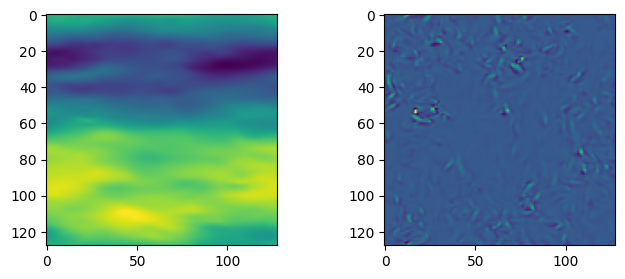

In [308]:
t = 5
y = 10

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(p.real[t, :, y, :])
axes[1].imshow(data[t, 4, :, y, :])
plt.show()

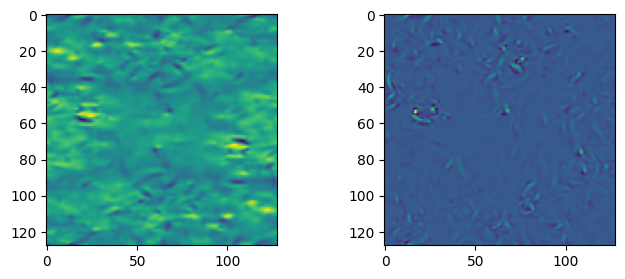

In [289]:
t = 5
y = 10

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(p.real[t, :, y, :])
axes[1].imshow(data[t, 4, :, y, :])
plt.show()

In [316]:
import numpy as np

# --- build a simple channel-like grid ---
nx, ny, nz = 32, 65, 32
Lx, Lz = 2*np.pi, 2*np.pi

x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, np.pi, ny)          # Neumann-friendly domain, 0 to pi
z = np.linspace(0, Lz, nz, endpoint=False)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")   # shape (nx, ny, nz)

# --- known analytical pressure field ---
p_exact = np.cos(X) * np.cos(Y) * np.cos(Z)

# --- exact Laplacian, computed by hand from the closed form ---
# d2/dx2[cos(x)] = -cos(x), same for y and z factors individually
laplacian_p_exact = -3 * p_exact   # sum of three -p_exact contributions

# --- corresponding Q, from grad2p = 2*Q  =>  Q = grad2p / 2 ---
Q_exact = laplacian_p_exact / 2

# add a dummy time axis T=1 to match your pressure_solve's expected shape (T, nx, ny, nz)
p_exact_T = p_exact[None, ...]
Q_exact_T = Q_exact[None, ...]

# build the "channel" dict your pressure_solve expects
channel = {"x": x, "y": y, "z": z}

# now test:
p_recovered = pressure_solve(channel, Q_exact_T)
# compare p_recovered.real against p_exact_T (up to an additive constant)

skipped K: -0.0


In [318]:
p_recovered.shape

(1, 32, 65, 32)

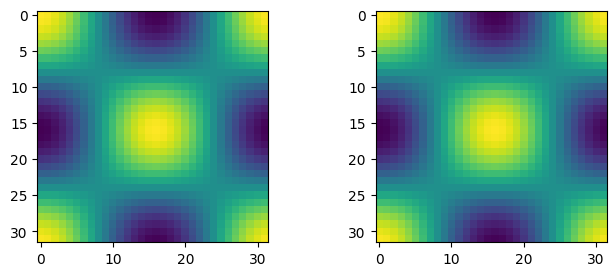

In [319]:
t = 0
y = 10

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(p_recovered.real[t, :, y, :])
axes[1].imshow(p_exact_T[t, :, y, :])
plt.show()

In [320]:
rel_rmse(p_recovered.real, p_exact_T)

np.float64(4.473291769274759e-07)